# Proyecto No. 1 — Flujo de potencia en una microrred de 4 barras

**Métodos Numéricos · Universidad del Valle de Guatemala · Semestre II 2026**

---

## 0. Planteamiento del problema

Una microrred es una red eléctrica de baja o media tensión que integra generación distribuida
(paneles fotovoltaicos, baterías, generadores diésel) y cargas locales, y que puede operar
conectada a la red principal o de forma aislada.

El problema de flujo de potencia consiste en determinar el estado eléctrico completo de la
red (la magnitud y el ángulo de fase del voltaje en cada barra) a partir de las potencias
inyectadas o consumidas que se conocen de antemano. Con ese estado se calculan después los
flujos por cada línea, las pérdidas y se verifica si los voltajes están dentro de límites
operativos.

Este problema no se puede resolver despejando variable por variable: la potencia inyectada
en una barra depende del voltaje de todas las barras vecinas a través de productos de
magnitudes por senos y cosenos de diferencias angulares. Las incógnitas están acopladas y el
sistema es intrínsecamente no lineal.

### Sistema estudiado

Microrred **mallada** de 4 barras. Se elige topología mallada (5 líneas) y no radial, porque
así la salida de una línea no deja barras aisladas y el estudio de contingencias sigue teniendo
solución.

| Barra | Tipo | Elemento físico | Datos conocidos | Incógnitas |
|-------|------|-----------------|-----------------|------------|
| 1 | Slack | Acople a la red principal | $\lvert V_1\rvert = 1.00$, $\delta_1 = 0$ | $P_1$, $Q_1$ |
| 2 | PV | Generador fotovoltaico con regulación | $P_2 = 0.40$, $\lvert V_2\rvert = 1.02$ | $\delta_2$, $Q_2$ |
| 3 | PQ | Carga | $P_3 = -0.50$, $Q_3 = -0.30$ | $\lvert V_3\rvert$, $\delta_3$ |
| 4 | PQ | Carga | $P_4 = -0.35$, $Q_4 = -0.20$ | $\lvert V_4\rvert$, $\delta_4$ |

Vector de incógnitas: $\mathbf{x} = [\delta_2,\ \delta_3,\ \delta_4,\ \lvert V_3\rvert,\ \lvert V_4\rvert]^T \in \mathbb{R}^5$.

**Sistema de 5 ecuaciones no lineales acopladas.**

Las impedancias corresponden a conductor de distribución, con relación $R/X \approx 0.7$.
Esto es relevante: a diferencia de las redes de transmisión ($R/X \ll 1$), aquí el
desacoplamiento clásico $P$–$\delta$ / $Q$–$V$ **no es válido**, por lo que se descarta el
método de flujo de potencia desacoplado rápido y se usa Newton-Raphson completo.

Todas las cantidades están en por unidad (p.u.) sobre una base de 1 MVA.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True, linewidth=110)
plt.rcParams.update({"figure.dpi": 110, "font.size": 10, "axes.grid": True,
                     "grid.alpha": 0.3, "figure.autolayout": True})

# ---- Identificadores de tipo de barra ----
SLACK, PV, PQ = 0, 1, 2

# ---- Datos de línea: (barra_i, barra_j, R [p.u.], X [p.u.]) ----
LINEAS = [(1, 2, 0.04, 0.06),
          (1, 3, 0.05, 0.07),
          (2, 3, 0.03, 0.05),
          (2, 4, 0.06, 0.08),
          (3, 4, 0.05, 0.06)]

N = 4                                        # número de barras
TIPOS  = np.array([SLACK, PV, PQ, PQ])       # tipo de cada barra
V_ESP  = np.array([1.00, 1.02, 1.00, 1.00])  # |V| especificado (slack y PV) / inicial (PQ)
P_PROG = np.array([0.00, 0.40, -0.50, -0.35])  # P programada (negativa = carga)
Q_PROG = np.array([0.00, 0.00, -0.30, -0.20])  # Q programada

print("Relación R/X de cada línea:")
for (i, j, R, X) in LINEAS:
    print(f"  Línea {i}-{j}:  R/X = {R/X:.3f}")
print(f"\nCarga total:      P = {-P_PROG[2:].sum():.2f} p.u.")
print(f"Generación local: P = {P_PROG[1]:.2f} p.u.")

Relación R/X de cada línea:
  Línea 1-2:  R/X = 0.667
  Línea 1-3:  R/X = 0.714
  Línea 2-3:  R/X = 0.600
  Línea 2-4:  R/X = 0.750
  Línea 3-4:  R/X = 0.833

Carga total:      P = 0.85 p.u.
Generación local: P = 0.40 p.u.


---

## 1. Modelado matemático

### 1.1 Matriz de admitancias $Y_{bus}$

La relación entre corrientes y voltajes nodales es lineal: $\mathbf{I} = Y_{bus}\mathbf{V}$.
Para una red sin transformadores desfasadores ni admitancias en derivación, la matriz se
ensambla con dos reglas, donde $y_{ik} = 1/z_{ik} = 1/(R_{ik} + jX_{ik})$:

$$Y_{ii} = \sum_{k \neq i} y_{ik}, \qquad Y_{ik} = -y_{ik} \ \ (i \neq k)$$

Se escribe $Y_{bus} = G + jB$, donde $G$ es la matriz de conductancias y $B$ la de
susceptancias. Ambas son reales y simétricas.

In [2]:
def construir_ybus(lineas, n):
    """
    Ensambla la matriz de admitancias nodales Y_bus.

    Parámetros
    ----------
    lineas : list[tuple]  lista de (i, j, R, X) con barras numeradas desde 1
    n      : int          número de barras

    Retorna
    -------
    Y : ndarray (n,n) complejo
    """
    Y = np.zeros((n, n), dtype=complex)
    for (i, j, R, X) in lineas:
        i, j = i - 1, j - 1            # a indexación desde 0
        y = 1.0 / complex(R, X)        # admitancia serie de la línea
        Y[i, i] += y                   # diagonal: suma de admitancias incidentes
        Y[j, j] += y
        Y[i, j] -= y                   # fuera de diagonal: admitancia negada
        Y[j, i] -= y
    return Y


Y = construir_ybus(LINEAS, N)
G, B = Y.real, Y.imag

print("Y_bus (parte real G):"); print(G)
print("\nY_bus (parte imaginaria B):"); print(B)
print("\nSimétrica:", np.allclose(Y, Y.T))
print("Y[0,3] = 0 (no hay línea 1-4):", np.isclose(abs(Y[0, 3]), 0))

Y_bus (parte real G):
[[14.449064 -7.692308 -6.756757  0.      ]
 [-7.692308 22.515837 -8.823529 -6.      ]
 [-6.756757 -8.823529 23.777007 -8.196721]
 [ 0.       -6.       -8.196721 14.196721]]

Y_bus (parte imaginaria B):
[[-20.997921  11.538462   9.459459   0.      ]
 [ 11.538462 -34.244344  14.705882   8.      ]
 [  9.459459  14.705882 -34.001407   9.836066]
 [  0.         8.         9.836066 -17.836066]]

Simétrica: True
Y[0,3] = 0 (no hay línea 1-4): True


### 1.2 Ecuaciones de inyección de potencia

Partiendo de $S_i = V_i I_i^*$ con $I_i = \sum_k Y_{ik} V_k$ y escribiendo
$V_i = \lvert V_i\rvert e^{j\delta_i}$, se separan parte real e imaginaria:

$$P_i = \sum_{k=1}^{n} \lvert V_i\rvert\,\lvert V_k\rvert \left( G_{ik}\cos\delta_{ik} + B_{ik}\sin\delta_{ik} \right)$$

$$Q_i = \sum_{k=1}^{n} \lvert V_i\rvert\,\lvert V_k\rvert \left( G_{ik}\sin\delta_{ik} - B_{ik}\cos\delta_{ik} \right)$$

con $\delta_{ik} = \delta_i - \delta_k$. Aquí se ve el acoplamiento: $P_i$ depende de **todos**
los voltajes y ángulos vecinos, de forma trigonométrica.

### 1.3 Vector de residuos $\mathbf{F}(\mathbf{x})$

El sistema a resolver es $\mathbf{F}(\mathbf{x}) = \mathbf{0}$, donde cada componente es la
diferencia entre la potencia programada y la calculada (el *mismatch*):

$$\mathbf{F}(\mathbf{x}) = \begin{bmatrix}
P_2^{prog} - P_2(\mathbf{x}) \\
P_3^{prog} - P_3(\mathbf{x}) \\
P_4^{prog} - P_4(\mathbf{x}) \\
Q_3^{prog} - Q_3(\mathbf{x}) \\
Q_4^{prog} - Q_4(\mathbf{x})
\end{bmatrix}$$

Se excluye la barra slack (sus potencias son incógnitas, no datos) y se excluye $Q_2$ (la barra
PV regula su voltaje inyectando el reactivo que haga falta, así que $Q_2$ tampoco es dato).

In [3]:
def calcular_inyecciones(V, delta, G, B):
    """
    Evalúa las potencias activa y reactiva inyectadas en cada barra.

    Parámetros
    ----------
    V, delta : ndarray (n,)   magnitudes y ángulos [rad] de voltaje
    G, B     : ndarray (n,n)  partes real e imaginaria de Y_bus

    Retorna
    -------
    P, Q : ndarray (n,)
    """
    n = len(V)
    P = np.zeros(n)
    Q = np.zeros(n)
    for i in range(n):
        for k in range(n):
            dik = delta[i] - delta[k]
            P[i] += V[i] * V[k] * (G[i, k] * np.cos(dik) + B[i, k] * np.sin(dik))
            Q[i] += V[i] * V[k] * (G[i, k] * np.sin(dik) - B[i, k] * np.cos(dik))
    return P, Q


def indices_incognitas(tipos):
    """Índices de barras que aportan incógnita de ángulo (no slack) y de magnitud (solo PQ)."""
    idx_ang = [i for i in range(len(tipos)) if tipos[i] != SLACK]
    idx_mag = [i for i in range(len(tipos)) if tipos[i] == PQ]
    return idx_ang, idx_mag


def residuos(V, delta, G, B, P_prog, Q_prog, idx_ang, idx_mag):
    """Vector F(x) de desajustes de potencia."""
    P, Q = calcular_inyecciones(V, delta, G, B)
    return np.concatenate([P_prog[idx_ang] - P[idx_ang],
                           Q_prog[idx_mag] - Q[idx_mag]])


IDX_ANG, IDX_MAG = indices_incognitas(TIPOS)
print("Barras con incógnita de ángulo   (0-index):", IDX_ANG)
print("Barras con incógnita de magnitud (0-index):", IDX_MAG)
print("Dimensión del sistema:", len(IDX_ANG) + len(IDX_MAG))

# Evaluación de F en el arranque plano (flat start): V=V_esp, delta=0
F0 = residuos(V_ESP.copy(), np.zeros(N), G, B, P_PROG, Q_PROG, IDX_ANG, IDX_MAG)
print("\nF(x0) en arranque plano:", F0)
print("Norma infinito inicial:", np.max(np.abs(F0)))

Barras con incógnita de ángulo   (0-index): [1, 2, 3]
Barras con incógnita de magnitud (0-index): [2, 3]
Dimensión del sistema: 5

F(x0) en arranque plano: [-0.059323 -0.323529 -0.23     -0.005882 -0.04    ]
Norma infinito inicial: 0.32352941176470473


---

## 2. Metodología numérica

### 2.1 Por qué Newton-Raphson multivariado

El sistema tiene **dos niveles anidados**:

1. **Nivel externo (no lineal).** Las ecuaciones de inyección son trascendentes en $\delta$ y
   cuadráticas en $\lvert V\rvert$. No admiten despeje algebraico. Se usa Newton-Raphson
   multivariado, que converge cuadráticamente cerca de la raíz.
2. **Nivel interno (lineal).** Cada iteración de Newton requiere resolver el sistema lineal
   $J\,\Delta\mathbf{x} = \mathbf{F}(\mathbf{x})$. Aquí sí se elige entre método directo o
   iterativo.

Para el nivel interno se usa **eliminación gaussiana con pivoteo parcial**. La justificación:

- El sistema es pequeño ($5\times 5$) y **denso**, así que un método directo cuesta
  $O(n^3/3)$ operaciones y termina de una vez, sin pregunta de convergencia.
- La Jacobiana **no es diagonalmente dominante** en general (se verifica numéricamente más
  abajo), por lo que Jacobi y Gauss-Seidel no tienen garantía de convergencia sobre ella.
- El pivoteo parcial no es decorativo: cerca del límite de cargabilidad la Jacobiana se
  vuelve casi singular y aparecen pivotes pequeños. Sin intercambio de filas, el error de
  redondeo se amplifica.

### 2.2 Derivación de la Jacobiana analítica

Se calcula $J = \partial(P,Q)/\partial(\delta,\lvert V\rvert)$ en cuatro bloques:

$$J = \begin{bmatrix} H & N \\ M & L \end{bmatrix} =
\begin{bmatrix}
\partial P/\partial\delta & \partial P/\partial \lvert V\rvert \\
\partial Q/\partial\delta & \partial Q/\partial \lvert V\rvert
\end{bmatrix}$$

**Elementos fuera de la diagonal** ($i \neq k$), derivando directamente las sumatorias:

$$\frac{\partial P_i}{\partial \delta_k} = \lvert V_i\rvert \lvert V_k\rvert (G_{ik}\sin\delta_{ik} - B_{ik}\cos\delta_{ik})
\qquad
\frac{\partial P_i}{\partial \lvert V_k\rvert} = \lvert V_i\rvert (G_{ik}\cos\delta_{ik} + B_{ik}\sin\delta_{ik})$$

$$\frac{\partial Q_i}{\partial \delta_k} = -\lvert V_i\rvert \lvert V_k\rvert (G_{ik}\cos\delta_{ik} + B_{ik}\sin\delta_{ik})
\qquad
\frac{\partial Q_i}{\partial \lvert V_k\rvert} = \lvert V_i\rvert (G_{ik}\sin\delta_{ik} - B_{ik}\cos\delta_{ik})$$

**Elementos diagonales.** Al derivar respecto de la propia variable, el término $k=i$ de la
sumatoria contribuye aparte. Agrupando y reconociendo las propias sumatorias de $P_i$ y $Q_i$
se llega a formas compactas que reutilizan las inyecciones ya calculadas:

$$\frac{\partial P_i}{\partial \delta_i} = -Q_i - B_{ii}\lvert V_i\rvert^2
\qquad
\frac{\partial P_i}{\partial \lvert V_i\rvert} = \frac{P_i}{\lvert V_i\rvert} + G_{ii}\lvert V_i\rvert$$

$$\frac{\partial Q_i}{\partial \delta_i} = P_i - G_{ii}\lvert V_i\rvert^2
\qquad
\frac{\partial Q_i}{\partial \lvert V_i\rvert} = \frac{Q_i}{\lvert V_i\rvert} - B_{ii}\lvert V_i\rvert$$

Esto es más eficiente y más estable que aproximar por diferencias finitas.

In [4]:
def jacobiana(V, delta, G, B, idx_ang, idx_mag):
    """
    Jacobiana analítica del flujo de potencia, ensamblada por bloques [[H, N], [M, L]].

    Filas: ecuaciones de P (barras no slack) seguidas de ecuaciones de Q (barras PQ).
    Columnas: incógnitas de ángulo seguidas de incógnitas de magnitud.

    Retorna
    -------
    J : ndarray (na+nm, na+nm)
    """
    P, Q = calcular_inyecciones(V, delta, G, B)
    na, nm = len(idx_ang), len(idx_mag)
    J = np.zeros((na + nm, na + nm))

    # ---- Bloque H = dP/d(delta)  y  bloque N = dP/d|V| ----
    for a, i in enumerate(idx_ang):
        for b, k in enumerate(idx_ang):
            if i == k:
                J[a, b] = -Q[i] - B[i, i] * V[i] ** 2
            else:
                dik = delta[i] - delta[k]
                J[a, b] = V[i] * V[k] * (G[i, k] * np.sin(dik) - B[i, k] * np.cos(dik))
        for b, k in enumerate(idx_mag):
            if i == k:
                J[a, na + b] = P[i] / V[i] + G[i, i] * V[i]
            else:
                dik = delta[i] - delta[k]
                J[a, na + b] = V[i] * (G[i, k] * np.cos(dik) + B[i, k] * np.sin(dik))

    # ---- Bloque M = dQ/d(delta)  y  bloque L = dQ/d|V| ----
    for a, i in enumerate(idx_mag):
        for b, k in enumerate(idx_ang):
            if i == k:
                J[na + a, b] = P[i] - G[i, i] * V[i] ** 2
            else:
                dik = delta[i] - delta[k]
                J[na + a, b] = -V[i] * V[k] * (G[i, k] * np.cos(dik) + B[i, k] * np.sin(dik))
        for b, k in enumerate(idx_mag):
            if i == k:
                J[na + a, na + b] = Q[i] / V[i] - B[i, i] * V[i]
            else:
                dik = delta[i] - delta[k]
                J[na + a, na + b] = V[i] * (G[i, k] * np.sin(dik) - B[i, k] * np.cos(dik))
    return J


J0 = jacobiana(V_ESP.copy(), np.zeros(N), G, B, IDX_ANG, IDX_MAG)
print("Jacobiana en el arranque plano:"); print(J0)
print("\nNúmero de condición:", np.linalg.cond(J0))

# ¿Es diagonalmente dominante? Esto justifica descartar Jacobi/Gauss-Seidel sobre J.
dom = np.all(np.abs(np.diag(J0)) > np.sum(np.abs(J0), axis=1) - np.abs(np.diag(J0)))
print("¿Diagonalmente dominante por filas?", dom)

Jacobiana en el arranque plano:
[[ 34.929231 -15.        -8.16      -9.        -6.12    ]
 [-15.        34.295525  -9.836066  23.600537  -8.196721]
 [ -8.16      -9.836066  17.996066  -8.196721  14.076721]
 [  9.       -23.953478   8.196721  33.70729   -9.836066]
 [  6.12       8.196721 -14.316721  -9.836066  17.676066]]

Número de condición: 8.525676628929018
¿Diagonalmente dominante por filas? False


### 2.3 Validación de la Jacobiana

Antes de confiar en las fórmulas analíticas se comparan contra una aproximación por
**diferencias centradas**, que tiene error $O(h^2)$:

$$\frac{\partial F_i}{\partial x_j} \approx \frac{F_i(\mathbf{x} + h\mathbf{e}_j) - F_i(\mathbf{x} - h\mathbf{e}_j)}{2h}$$

Se evalúa en un punto arbitrario (no en el arranque plano) para que la prueba sea significativa.

In [5]:
def empaquetar(x, V_esp, tipos, idx_ang, idx_mag):
    """Convierte el vector de incógnitas x en arreglos completos (V, delta)."""
    V = V_esp.copy()
    delta = np.zeros(len(tipos))
    delta[idx_ang] = x[:len(idx_ang)]
    V[idx_mag] = x[len(idx_ang):]
    return V, delta


def jacobiana_numerica(x, V_esp, tipos, G, B, idx_ang, idx_mag, h=1e-6):
    """Jacobiana de (P,Q) por diferencias centradas, solo para validación."""
    def eval_pq(xv):
        V, d = empaquetar(xv, V_esp, tipos, idx_ang, idx_mag)
        P, Q = calcular_inyecciones(V, d, G, B)
        return np.concatenate([P[idx_ang], Q[idx_mag]])

    m = len(x)
    Jn = np.zeros((m, m))
    for j in range(m):
        e = np.zeros(m); e[j] = h
        Jn[:, j] = (eval_pq(x + e) - eval_pq(x - e)) / (2 * h)
    return Jn


x_prueba = np.array([0.010, -0.020, -0.030, 0.980, 0.970])
V_p, d_p = empaquetar(x_prueba, V_ESP, TIPOS, IDX_ANG, IDX_MAG)

J_ana = jacobiana(V_p, d_p, G, B, IDX_ANG, IDX_MAG)
J_num = jacobiana_numerica(x_prueba, V_ESP, TIPOS, G, B, IDX_ANG, IDX_MAG)

err_abs = np.max(np.abs(J_ana - J_num))
print(f"Error máximo absoluto  ||J_analítica - J_numérica||_inf = {err_abs:.3e}")
print(f"Error máximo relativo                                   = {err_abs/np.max(np.abs(J_ana)):.3e}")
print("\nLa concordancia al nivel del error de truncamiento O(h^2) confirma la derivación.")

Error máximo absoluto  ||J_analítica - J_numérica||_inf = 2.611e-09
Error máximo relativo                                   = 7.469e-11

La concordancia al nivel del error de truncamiento O(h^2) confirma la derivación.


### 2.4 Solucionadores lineales implementados desde cero

Se implementan dos métodos directos. **Gauss con pivoteo parcial** es el que usa el Newton;
**Gauss-Jordan** se incluye para contrastar costo operativo y para calcular la inversa de $J$
en el análisis de sensibilidad.

En cada columna $c$, el pivoteo parcial busca
$p = \arg\max_{r \geq c} \lvert a_{rc}\rvert$ e intercambia las filas $c$ y $p$. Esto acota
el factor de crecimiento de los multiplicadores a $\lvert m_{rc}\rvert \leq 1$, evitando que
el error de redondeo se amplifique cuando el pivote natural es pequeño.

In [6]:
def gauss_pivoteo(A, b):
    """
    Resuelve A x = b por eliminación gaussiana con pivoteo parcial.

    Retorna
    -------
    x           : ndarray (n,)  solución
    intercambios: int           número de permutaciones de fila realizadas
    det         : float         determinante (subproducto de la factorización)
    """
    n = len(b)
    M = np.hstack([np.asarray(A, dtype=float).copy(),
                   np.asarray(b, dtype=float).reshape(-1, 1)])
    intercambios = 0

    # --- Eliminación hacia adelante ---
    for col in range(n):
        p = col + int(np.argmax(np.abs(M[col:, col])))      # fila del pivote de mayor módulo
        if abs(M[p, col]) < 1e-14:
            raise np.linalg.LinAlgError(f"Matriz singular: pivote nulo en columna {col}")
        if p != col:
            M[[col, p]] = M[[p, col]]                        # intercambio de filas
            intercambios += 1
        for fila in range(col + 1, n):
            m = M[fila, col] / M[col, col]                   # multiplicador
            M[fila, col:] -= m * M[col, col:]

    # --- Sustitución hacia atrás ---
    x = np.zeros(n)
    for fila in range(n - 1, -1, -1):
        x[fila] = (M[fila, -1] - M[fila, fila+1:n] @ x[fila+1:n]) / M[fila, fila]

    det = ((-1) ** intercambios) * np.prod(np.diag(M[:, :n]))
    return x, intercambios, det


def gauss_jordan(A, b):
    """
    Resuelve A x = b por Gauss-Jordan con pivoteo parcial (reduce a matriz identidad).
    Retorna x y el número de operaciones aritméticas de eliminación.
    """
    n = len(b)
    M = np.hstack([np.asarray(A, dtype=float).copy(),
                   np.asarray(b, dtype=float).reshape(-1, 1)])
    ops = 0
    for col in range(n):
        p = col + int(np.argmax(np.abs(M[col:, col])))
        if abs(M[p, col]) < 1e-14:
            raise np.linalg.LinAlgError(f"Matriz singular en columna {col}")
        if p != col:
            M[[col, p]] = M[[p, col]]
        M[col] = M[col] / M[col, col]                       # normalizar fila pivote
        ops += n + 1
        for fila in range(n):                               # anular TODA la columna
            if fila != col and M[fila, col] != 0.0:
                M[fila] -= M[fila, col] * M[col]
                ops += 2 * (n + 1)
    return M[:, -1], ops


# --- Prueba de los solucionadores sobre la Jacobiana real del problema ---
b_prueba = residuos(V_p, d_p, G, B, P_PROG, Q_PROG, IDX_ANG, IDX_MAG)

x_g,  perm, det = gauss_pivoteo(J_ana, b_prueba)
x_gj, ops       = gauss_jordan(J_ana, b_prueba)
x_np            = np.linalg.solve(J_ana, b_prueba)          # solo verificación

print("Gauss con pivoteo :", x_g)
print("Gauss-Jordan      :", x_gj)
print("numpy.linalg.solve:", x_np, "  <- solo verificación")
print(f"\nIntercambios de fila realizados: {perm}")
print(f"Determinante de J: {det:.6e}   (numpy: {np.linalg.det(J_ana):.6e})")
print(f"\nError vs numpy — Gauss      : {np.max(np.abs(x_g  - x_np)):.3e}")
print(f"Error vs numpy — Gauss-Jordan: {np.max(np.abs(x_gj - x_np)):.3e}")
print(f"\nResiduo ||J x - b||_inf     : {np.max(np.abs(J_ana @ x_g - b_prueba)):.3e}")

Gauss con pivoteo : [-0.035165 -0.007035 -0.002826  0.011919  0.018052]
Gauss-Jordan      : [-0.035165 -0.007035 -0.002826  0.011919  0.018052]
numpy.linalg.solve: [-0.035165 -0.007035 -0.002826  0.011919  0.018052]   <- solo verificación

Intercambios de fila realizados: 0
Determinante de J: 9.564152e+06   (numpy: 9.564152e+06)

Error vs numpy — Gauss      : 7.806e-18
Error vs numpy — Gauss-Jordan: 6.072e-18

Residuo ||J x - b||_inf     : 2.220e-16


### 2.5 Algoritmo de Newton-Raphson para flujo de potencia

Se resuelve $\mathbf{F}(\mathbf{x}) = \mathbf{0}$ iterando:

$$J(\mathbf{x}^{(k)})\,\Delta\mathbf{x}^{(k)} = \mathbf{F}(\mathbf{x}^{(k)}), \qquad
\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} + \Delta\mathbf{x}^{(k)}$$

**Nota sobre el signo.** Newton clásico es $\mathbf{x}^{(k+1)} = \mathbf{x}^{(k)} - [\partial\mathbf{F}/\partial\mathbf{x}]^{-1}\mathbf{F}$.
Como $\mathbf{F}$ se definió como *programada menos calculada*, se tiene
$\partial \mathbf{F}/\partial\mathbf{x} = -J$, y los dos signos negativos se cancelan: el
incremento se **suma**.

El criterio de parada es $\lVert\mathbf{F}\rVert_\infty < \varepsilon$, es decir, el máximo
desajuste de potencia en cualquier barra, que tiene interpretación física directa en p.u.

In [7]:
def newton_flujo(Y, tipos, V_esp, P_prog, Q_prog, tol=1e-10, max_iter=30,
                 V0=None, delta0=None, verbose=False):
    """
    Flujo de potencia por Newton-Raphson multivariado.
    El sistema lineal de cada iteración se resuelve con gauss_pivoteo (implementación propia).

    Parámetros
    ----------
    Y        : ndarray (n,n) complejo, matriz de admitancias
    tipos    : ndarray (n,)  SLACK / PV / PQ
    V_esp    : ndarray (n,)  magnitudes especificadas
    P_prog, Q_prog : ndarray (n,)  potencias programadas
    tol      : float  tolerancia sobre ||F||_inf
    max_iter : int    tope de iteraciones
    V0, delta0 : ndarray o None  punto inicial (None = arranque plano)

    Retorna
    -------
    dict con: V, delta, iteraciones, error, historial, convergio, J_final
    """
    G, B = Y.real, Y.imag
    n = len(tipos)
    idx_ang, idx_mag = indices_incognitas(tipos)

    # --- Punto inicial ---
    V     = V_esp.copy() if V0 is None else np.asarray(V0, dtype=float).copy()
    delta = np.zeros(n)  if delta0 is None else np.asarray(delta0, dtype=float).copy()
    for i in range(n):                       # slack y PV mantienen su |V| fijo siempre
        if tipos[i] != PQ:
            V[i] = V_esp[i]
        if tipos[i] == SLACK:
            delta[i] = 0.0

    historial = []
    na = len(idx_ang)

    for it in range(max_iter + 1):
        F = residuos(V, delta, G, B, P_prog, Q_prog, idx_ang, idx_mag)
        err = np.max(np.abs(F))
        historial.append(err)
        if verbose:
            print(f"  iter {it:2d} | ||F||_inf = {err:.6e}")
        if err < tol:
            J = jacobiana(V, delta, G, B, idx_ang, idx_mag)
            return dict(V=V, delta=delta, iteraciones=it, error=err,
                        historial=historial, convergio=True, J_final=J)
        if it == max_iter:
            break

        J = jacobiana(V, delta, G, B, idx_ang, idx_mag)
        try:
            dx, _, _ = gauss_pivoteo(J, F)          # <-- solucionador propio
        except np.linalg.LinAlgError:
            break
        delta[idx_ang] += dx[:na]                   # actualización de ángulos
        V[idx_mag]     += dx[na:]                   # actualización de magnitudes

    return dict(V=V, delta=delta, iteraciones=len(historial) - 1,
                error=historial[-1], historial=historial, convergio=False,
                J_final=jacobiana(V, delta, G, B, idx_ang, idx_mag))


print("Caso base — traza de convergencia:")
sol = newton_flujo(Y, TIPOS, V_ESP, P_PROG, Q_PROG, verbose=True)
print(f"\nConvergió: {sol['convergio']} en {sol['iteraciones']} iteraciones")

Caso base — traza de convergencia:
  iter  0 | ||F||_inf = 3.235294e-01
  iter  1 | ||F||_inf = 4.708884e-03
  iter  2 | ||F||_inf = 2.237039e-06
  iter  3 | ||F||_inf = 3.971823e-13

Convergió: True en 3 iteraciones


---

## 3. Resultados del caso base

### 3.1 Estado de la red

In [8]:
def resumen_estado(Y, tipos, sol, P_prog, Q_prog):
    """Arma la tabla del estado de la red y las potencias de las barras de generación."""
    V, delta = sol["V"], sol["delta"]
    P, Q = calcular_inyecciones(V, delta, Y.real, Y.imag)
    print(f"{'Barra':>5} {'Tipo':>6} {'|V| [p.u.]':>11} {'delta [°]':>10} "
          f"{'P [p.u.]':>10} {'Q [p.u.]':>10}")
    print("-" * 58)
    nombres = {SLACK: "Slack", PV: "PV", PQ: "PQ"}
    for i in range(len(tipos)):
        print(f"{i+1:>5} {nombres[tipos[i]]:>6} {V[i]:>11.5f} "
              f"{np.degrees(delta[i]):>10.4f} {P[i]:>10.5f} {Q[i]:>10.5f}")
    return P, Q


P_cal, Q_cal = resumen_estado(Y, TIPOS, sol, P_PROG, Q_PROG)

print(f"\nPotencia aportada por la red principal (slack): "
      f"P1 = {P_cal[0]:.5f}, Q1 = {Q_cal[0]:.5f} p.u.")
print(f"Reactivo inyectado por el generador PV:         Q2 = {Q_cal[1]:.5f} p.u.")
print(f"\nBalance de potencia activa:")
print(f"  Generación total = {P_cal[0] + P_cal[1]:.5f}")
print(f"  Carga total      = {-(P_PROG[2] + P_PROG[3]):.5f}")
print(f"  Pérdidas óhmicas = {P_cal.sum():.5f} p.u.  "
      f"({100*P_cal.sum()/(P_cal[0]+P_cal[1]):.2f} % de la generación)")

Barra   Tipo  |V| [p.u.]  delta [°]   P [p.u.]   Q [p.u.]
----------------------------------------------------------
    1  Slack     1.00000     0.0000    0.47862   -0.53388
    2     PV     1.02000    -1.4972    0.40000    1.07618
    3     PQ     0.99142    -1.5990   -0.50000   -0.30000
    4     PQ     0.98732    -1.9528   -0.35000   -0.20000

Potencia aportada por la red principal (slack): P1 = 0.47862, Q1 = -0.53388 p.u.
Reactivo inyectado por el generador PV:         Q2 = 1.07618 p.u.

Balance de potencia activa:
  Generación total = 0.87862
  Carga total      = 0.85000
  Pérdidas óhmicas = 0.02862 p.u.  (3.26 % de la generación)


### 3.2 Flujos por línea y pérdidas

Con el estado ya conocido se calculan las cantidades de interés operativo. Para la línea
$i\!-\!k$ con admitancia serie $y_{ik}$:

$$S_{ik} = V_i \left[ (V_i - V_k)\, y_{ik} \right]^*$$

Las pérdidas de la línea son $S_{ik} + S_{ki}$, que es no nulo porque la corriente disipa en la
resistencia serie.

In [9]:
def flujos_por_linea(lineas, V, delta):
    """Calcula el flujo complejo en ambos extremos de cada línea y sus pérdidas."""
    Vc = V * np.exp(1j * delta)          # fasores de voltaje
    filas = []
    for (i, j, R, X) in lineas:
        a, b = i - 1, j - 1
        y = 1.0 / complex(R, X)
        S_ij = Vc[a] * np.conj((Vc[a] - Vc[b]) * y)
        S_ji = Vc[b] * np.conj((Vc[b] - Vc[a]) * y)
        filas.append((i, j, S_ij, S_ji, S_ij + S_ji))
    return filas


filas = flujos_por_linea(LINEAS, sol["V"], sol["delta"])
print(f"{'Línea':>7} {'P_ij':>9} {'Q_ij':>9} {'P_ji':>9} {'Q_ji':>9} "
      f"{'Pérd. P':>9} {'Pérd. Q':>9}")
print("-" * 66)
perd_total = 0
for (i, j, Sij, Sji, Sp) in filas:
    print(f"{i}-{j:<5} {Sij.real:>9.5f} {Sij.imag:>9.5f} "
          f"{Sji.real:>9.5f} {Sji.imag:>9.5f} {Sp.real:>9.5f} {Sp.imag:>9.5f}")
    perd_total += Sp.real
print("-" * 66)
print(f"{'TOTAL':>7} {'':>39} {perd_total:>9.5f}")
print(f"\nCoincide con la suma de inyecciones: {np.isclose(perd_total, P_cal.sum())}")

  Línea      P_ij      Q_ij      P_ji      Q_ji   Pérd. P   Pérd. Q
------------------------------------------------------------------
1-2       0.15635  -0.43176  -0.14791   0.44441   0.00843   0.01265
1-3       0.32227  -0.10212  -0.31656   0.11012   0.00571   0.00800
2-3       0.28364   0.41286  -0.27641  -0.40080   0.00723   0.01206
2-4       0.26427   0.21891  -0.25748  -0.20986   0.00679   0.00906
3-4       0.09296  -0.00933  -0.09252   0.00986   0.00044   0.00053
------------------------------------------------------------------
  TOTAL                                           0.02862

Coincide con la suma de inyecciones: True


### 3.3 Convergencia cuadrática

El sello de Newton-Raphson es que el error se eleva al cuadrado en cada paso cerca de la raíz:
si $e_{k+1} \approx C\,e_k^2$, entonces el número de dígitos correctos se duplica por iteración.
Se verifica calculando el orden de convergencia observado:

$$p \approx \frac{\ln(e_{k+1}/e_k)}{\ln(e_k/e_{k-1})}$$

 Iter      ||F||_inf   Dígitos   Orden p
------------------------------------------
    0     3.2353e-01      0.49         —
    1     4.7089e-03      2.33     1.809
    2     2.2370e-06      5.65     2.031
    3     3.9718e-13     12.40         —

El orden observado ~2 confirma la convergencia cuadrática teórica.


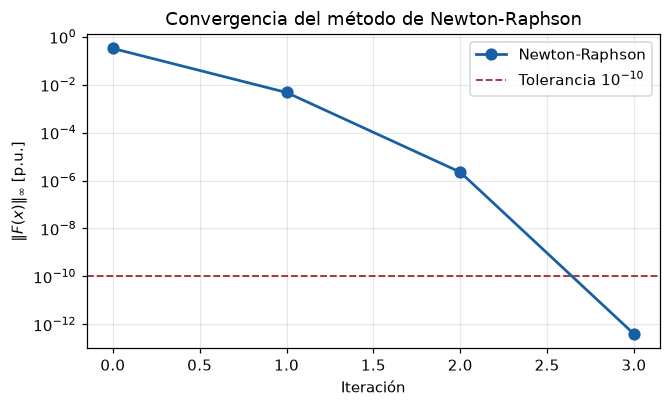

In [10]:
hist = np.array(sol["historial"])
print(f"{'Iter':>5} {'||F||_inf':>14} {'Dígitos':>9} {'Orden p':>9}")
print("-" * 42)
for k, e in enumerate(hist):
    dig = -np.log10(e) if e > 0 else np.inf
    if 1 <= k < len(hist) - 1 and hist[k-1] > 0 and hist[k] > 0:
        p = np.log(hist[k+1] / hist[k]) / np.log(hist[k] / hist[k-1])
        print(f"{k:>5} {e:>14.4e} {dig:>9.2f} {p:>9.3f}")
    else:
        print(f"{k:>5} {e:>14.4e} {dig:>9.2f} {'—':>9}")
print("\nEl orden observado ~2 confirma la convergencia cuadrática teórica.")

fig, ax = plt.subplots(figsize=(6.2, 3.8))
ax.semilogy(range(len(hist)), hist, "o-", color="#185FA5", lw=1.8, ms=7,
            label="Newton-Raphson")
ax.axhline(1e-10, color="#A32D2D", ls="--", lw=1.2, label="Tolerancia $10^{-10}$")
ax.set_xlabel("Iteración"); ax.set_ylabel(r"$\|F(x)\|_\infty$ [p.u.]")
ax.set_title("Convergencia del método de Newton-Raphson")
ax.legend(); plt.show()

---

## 4. Verificación y validación

Se verifica el resultado por **tres vías independientes**.

In [11]:
# --- (1) Sustitución directa en el sistema original ---
P_ver, Q_ver = calcular_inyecciones(sol["V"], sol["delta"], G, B)
print("(1) SUSTITUCIÓN EN EL SISTEMA ORIGINAL")
print(f"{'Ecuación':>10} {'Programado':>13} {'Calculado':>13} {'Residuo':>13}")
print("-" * 52)
for i in IDX_ANG:
    print(f"{'P'+str(i+1):>10} {P_PROG[i]:>13.6f} {P_ver[i]:>13.6f} "
          f"{P_PROG[i]-P_ver[i]:>13.2e}")
for i in IDX_MAG:
    print(f"{'Q'+str(i+1):>10} {Q_PROG[i]:>13.6f} {Q_ver[i]:>13.6f} "
          f"{Q_PROG[i]-Q_ver[i]:>13.2e}")
print(f"\nResiduo máximo: {sol['error']:.3e}")

(1) SUSTITUCIÓN EN EL SISTEMA ORIGINAL
  Ecuación    Programado     Calculado       Residuo
----------------------------------------------------
        P2      0.400000      0.400000     -1.71e-13
        P3     -0.500000     -0.500000     -1.69e-13
        P4     -0.350000     -0.350000     -2.35e-13
        Q3     -0.300000     -0.300000     -3.97e-13
        Q4     -0.200000     -0.200000      2.41e-14

Residuo máximo: 3.972e-13


In [12]:
# --- (2) Comparación contra scipy.optimize.fsolve (solo verificación) ---
from scipy.optimize import fsolve

def F_scipy(x):
    V, d = empaquetar(x, V_ESP, TIPOS, IDX_ANG, IDX_MAG)
    return residuos(V, d, G, B, P_PROG, Q_PROG, IDX_ANG, IDX_MAG)

x_scipy = fsolve(F_scipy, np.array([0., 0., 0., 1., 1.]), xtol=1e-13)
x_propio = np.concatenate([sol["delta"][IDX_ANG], sol["V"][IDX_MAG]])

print("(2) COMPARACIÓN CONTRA scipy.optimize.fsolve")
print(f"{'Incógnita':>12} {'Propio':>14} {'scipy':>14} {'|dif|':>12}")
print("-" * 55)
etq = [f"delta{i+1}" for i in IDX_ANG] + [f"|V{i+1}|" for i in IDX_MAG]
for e, a, b_ in zip(etq, x_propio, x_scipy):
    print(f"{e:>12} {a:>14.9f} {b_:>14.9f} {abs(a-b_):>12.2e}")
print(f"\nDiferencia máxima: {np.max(np.abs(x_propio - x_scipy)):.3e}")

(2) COMPARACIÓN CONTRA scipy.optimize.fsolve
   Incógnita         Propio          scipy        |dif|
-------------------------------------------------------
      delta2   -0.026131766   -0.026131766     2.70e-14
      delta3   -0.027908125   -0.027908125     1.92e-14
      delta4   -0.034082769   -0.034082769     3.18e-14
        |V3|    0.991421160    0.991421160     1.49e-14
        |V4|    0.987316025    0.987316025     1.40e-14

Diferencia máxima: 3.184e-14


### (3) Método independiente: Gauss-Seidel para flujo de potencia

Como tercera verificación se implementa un método **completamente distinto**: Gauss-Seidel
sobre la formulación fasorial, que no usa Jacobiana en absoluto. Despejando $V_i$ de
$S_i^* = V_i^*\sum_k Y_{ik}V_k$:

$$V_i^{(k+1)} = \frac{1}{Y_{ii}}\left[ \frac{P_i - jQ_i}{(V_i^{(k)})^*} - \sum_{k \neq i} Y_{ik}V_k \right]$$

Para la barra PV se estima primero $Q_i = -\text{Im}\{V_i^*\sum_k Y_{ik}V_k\}$ y después se
corrige la magnitud del resultado al valor especificado, conservando su ángulo.

Que dos métodos con formulaciones tan diferentes lleguen al mismo punto es evidencia fuerte
de que la solución es correcta.

In [13]:
def gauss_seidel_flujo(Y, tipos, V_esp, P_prog, Q_prog, tol=1e-10, max_iter=3000):
    """
    Flujo de potencia por Gauss-Seidel (formulación fasorial, sin Jacobiana).
    Método iterativo estacionario: converge linealmente.
    """
    n = len(tipos)
    Vc = np.array([complex(V_esp[i], 0.0) for i in range(n)])
    historial = []

    for it in range(1, max_iter + 1):
        V_ant = Vc.copy()
        for i in range(n):
            if tipos[i] == SLACK:
                continue
            if tipos[i] == PV:
                Qi = -np.imag(np.conj(Vc[i]) * (Y[i, :] @ Vc))   # Q estimado en barra PV
            else:
                Qi = Q_prog[i]
            suma = Y[i, :] @ Vc - Y[i, i] * Vc[i]                # aportes de las vecinas
            V_nuevo = ((P_prog[i] - 1j * Qi) / np.conj(Vc[i]) - suma) / Y[i, i]
            if tipos[i] == PV:
                V_nuevo = V_esp[i] * V_nuevo / abs(V_nuevo)      # forzar |V| especificado
            Vc[i] = V_nuevo                                      # actualización inmediata

        err = np.max(np.abs(Vc - V_ant))
        historial.append(err)
        if err < tol:
            return dict(V=np.abs(Vc), delta=np.angle(Vc), iteraciones=it,
                        error=err, historial=historial, convergio=True)

    return dict(V=np.abs(Vc), delta=np.angle(Vc), iteraciones=max_iter,
                error=historial[-1], historial=historial, convergio=False)


sol_gs = gauss_seidel_flujo(Y, TIPOS, V_ESP, P_PROG, Q_PROG)

print("(3) MÉTODO INDEPENDIENTE: GAUSS-SEIDEL")
print(f"Convergió: {sol_gs['convergio']} en {sol_gs['iteraciones']} iteraciones")
print(f"\n{'Barra':>6} {'|V| Newton':>13} {'|V| G-S':>13} {'|dif|':>11}")
print("-" * 46)
for i in range(N):
    print(f"{i+1:>6} {sol['V'][i]:>13.9f} {sol_gs['V'][i]:>13.9f} "
          f"{abs(sol['V'][i]-sol_gs['V'][i]):>11.2e}")
print(f"\nDiferencia máxima en magnitudes: {np.max(np.abs(sol['V']-sol_gs['V'])):.3e}")
print(f"Diferencia máxima en ángulos   : {np.max(np.abs(sol['delta']-sol_gs['delta'])):.3e}")

(3) MÉTODO INDEPENDIENTE: GAUSS-SEIDEL
Convergió: True en 53 iteraciones

 Barra    |V| Newton       |V| G-S       |dif|
----------------------------------------------
     1   1.000000000   1.000000000    0.00e+00
     2   1.020000000   1.020000000    0.00e+00
     3   0.991421160   0.991421160    2.11e-12
     4   0.987316025   0.987316025    2.27e-12

Diferencia máxima en magnitudes: 2.274e-12
Diferencia máxima en ángulos   : 2.083e-10


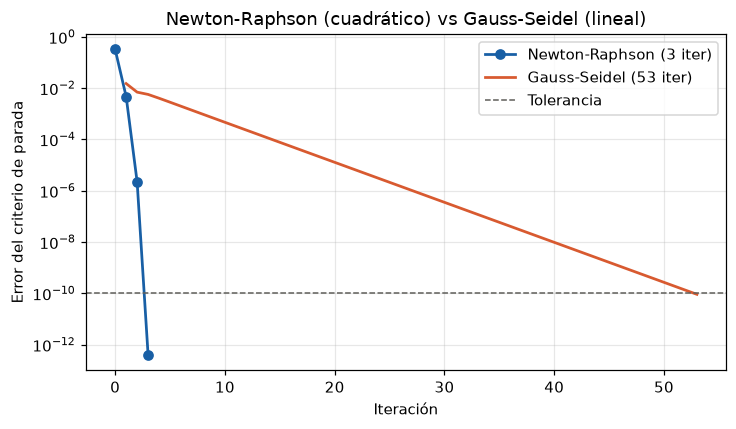

Newton necesita 3 iteraciones; Gauss-Seidel necesita 53.
Razón: 17.7x

Gauss-Seidel es más barato por iteración (no arma ni factoriza la Jacobiana),
pero su convergencia lineal lo vuelve impráctico al aumentar el tamaño de la red.


In [14]:
# --- Comparación gráfica de la velocidad de convergencia ---
fig, ax = plt.subplots(figsize=(6.8, 4.0))
ax.semilogy(range(len(sol["historial"])), sol["historial"], "o-",
            color="#185FA5", lw=1.8, ms=6, label=f"Newton-Raphson ({sol['iteraciones']} iter)")
ax.semilogy(range(1, len(sol_gs["historial"]) + 1), sol_gs["historial"], "-",
            color="#D85A30", lw=1.8, label=f"Gauss-Seidel ({sol_gs['iteraciones']} iter)")
ax.axhline(1e-10, color="#5F5E5A", ls="--", lw=1.0, label="Tolerancia")
ax.set_xlabel("Iteración"); ax.set_ylabel("Error del criterio de parada")
ax.set_title("Newton-Raphson (cuadrático) vs Gauss-Seidel (lineal)")
ax.legend(); plt.show()

print(f"Newton necesita {sol['iteraciones']} iteraciones; "
      f"Gauss-Seidel necesita {sol_gs['iteraciones']}.")
print(f"Razón: {sol_gs['iteraciones']/max(sol['iteraciones'],1):.1f}x")
print("\nGauss-Seidel es más barato por iteración (no arma ni factoriza la Jacobiana),")
print("pero su convergencia lineal lo vuelve impráctico al aumentar el tamaño de la red.")

---

## 5. Componente experimental

Se diseñan tres experimentos que exploran el comportamiento del modelo más allá de un único
caso numérico.

### Experimento 1 — Barrido de carga y colapso de voltaje

Se escala toda la carga por un factor $\lambda$ y se resuelve el flujo en cada paso, usando la
solución anterior como punto inicial (**continuación**). Esto traza la curva $\lvert V\rvert$
contra $\lambda$, conocida como **curva PV** o *curva de la nariz*.

La hipótesis física es que existe un $\lambda_{max}$ más allá del cual **no existe solución**:
la red alcanza su máxima transferencia de potencia. Numéricamente esto debe manifestarse como
la Jacobiana volviéndose singular, es decir, $\text{cond}(J) \to \infty$.

Se usa **paso adaptativo**: cuando Newton falla, se retrocede y se reduce el paso a la mitad,
lo que permite acercarse a la nariz con precisión.

In [15]:
def barrido_carga(Y, tipos, V_esp, P_prog, Q_prog, idx_carga,
                  lam_ini=1.0, paso_ini=0.25, paso_min=0.002, lam_tope=40.0):
    """
    Barrido de carga con paso adaptativo hasta el punto de colapso de voltaje.

    En cada valor de lambda se escalan las cargas y se resuelve el flujo partiendo
    de la solución anterior. Si Newton no converge, se retrocede y se reduce el paso.

    Retorna
    -------
    dict con arreglos lambdas, V (n_pasos x n_barras), cond_J, iteraciones, lam_max
    """
    lams, Vs, conds, iters = [], [], [], []
    V0, d0 = None, None
    lam, paso = lam_ini, paso_ini
    idx_ang, idx_mag = indices_incognitas(tipos)

    while paso > paso_min and lam < lam_tope:
        Pp, Qp = P_prog.copy(), Q_prog.copy()
        Pp[idx_carga] *= lam                       # escalar solo las cargas
        Qp[idx_carga] *= lam
        r = newton_flujo(Y, tipos, V_esp, Pp, Qp, V0=V0, delta0=d0, max_iter=60)

        if r["convergio"]:
            J = jacobiana(r["V"], r["delta"], Y.real, Y.imag, idx_ang, idx_mag)
            lams.append(lam); Vs.append(r["V"].copy())
            conds.append(np.linalg.cond(J)); iters.append(r["iteraciones"])
            V0, d0 = r["V"].copy(), r["delta"].copy()   # continuación
            lam += paso
        else:
            lam -= paso                            # retroceder
            paso /= 2.0                            # y afinar
            lam += paso

    return dict(lambdas=np.array(lams), V=np.array(Vs), cond_J=np.array(conds),
                iteraciones=np.array(iters), lam_max=lams[-1] if lams else np.nan)


bar = barrido_carga(Y, TIPOS, V_ESP, P_PROG, Q_PROG, idx_carga=[2, 3])

print(f"Factor de carga máximo alcanzado: lambda_max = {bar['lam_max']:.4f}")
print(f"Es decir, la red soporta {bar['lam_max']:.2f} veces la carga nominal.\n")
print(f"{'lambda':>8} {'|V3|':>9} {'|V4|':>9} {'cond(J)':>12} {'iter':>6}")
print("-" * 48)
sel = list(range(0, len(bar["lambdas"]), max(1, len(bar["lambdas"]) // 12))) + [-1]
for k in sel:
    print(f"{bar['lambdas'][k]:>8.4f} {bar['V'][k,2]:>9.5f} {bar['V'][k,3]:>9.5f} "
          f"{bar['cond_J'][k]:>12.1f} {bar['iteraciones'][k]:>6d}")

Factor de carga máximo alcanzado: lambda_max = 8.5195
Es decir, la red soporta 8.52 veces la carga nominal.

  lambda      |V3|      |V4|      cond(J)   iter
------------------------------------------------
  1.0000   0.99142   0.98732          8.7      3
  1.5000   0.97988   0.97208          8.8      3
  2.0000   0.96788   0.95629          8.9      3
  2.5000   0.95538   0.93985          9.0      3
  3.0000   0.94231   0.92271          9.1      3
  3.5000   0.92860   0.90476          9.3      3
  4.0000   0.91415   0.88587          9.5      3
  4.5000   0.89884   0.86590          9.8      3
  5.0000   0.88251   0.84464         10.2      3
  5.5000   0.86493   0.82180         10.6      3
  6.0000   0.84580   0.79699         11.2      3
  6.5000   0.82462   0.76960         12.1      3
  7.0000   0.80060   0.73862         13.4      3
  7.5000   0.77218   0.70211         15.7      4
  8.0000   0.73547   0.65526         20.9      4
  8.5000   0.66322   0.56536         96.3      6
  8.5195 

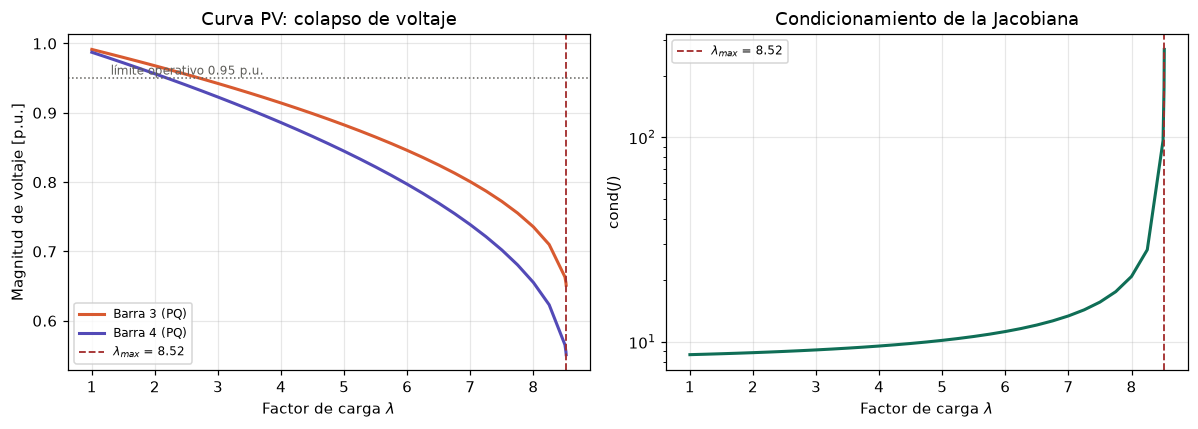

cond(J) en carga nominal (lambda=1):     8.7
cond(J) en el último punto convergido:   268.8
Factor de crecimiento:                   31x


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.0))

# --- Curva PV (curva de la nariz) ---
axes[0].plot(bar["lambdas"], bar["V"][:, 2], lw=2, color="#D85A30", label="Barra 3 (PQ)")
axes[0].plot(bar["lambdas"], bar["V"][:, 3], lw=2, color="#534AB7", label="Barra 4 (PQ)")
axes[0].axvline(bar["lam_max"], color="#A32D2D", ls="--", lw=1.2,
                label=f"$\\lambda_{{max}}$ = {bar['lam_max']:.2f}")
axes[0].axhline(0.95, color="#5F5E5A", ls=":", lw=1.0)
axes[0].text(1.3, 0.955, "límite operativo 0.95 p.u.", fontsize=8, color="#5F5E5A")
axes[0].set_xlabel(r"Factor de carga $\lambda$")
axes[0].set_ylabel("Magnitud de voltaje [p.u.]")
axes[0].set_title("Curva PV: colapso de voltaje")
axes[0].legend(fontsize=8)

# --- Número de condición de la Jacobiana ---
axes[1].semilogy(bar["lambdas"], bar["cond_J"], lw=2, color="#0F6E56")
axes[1].axvline(bar["lam_max"], color="#A32D2D", ls="--", lw=1.2,
                label=f"$\\lambda_{{max}}$ = {bar['lam_max']:.2f}")
axes[1].set_xlabel(r"Factor de carga $\lambda$")
axes[1].set_ylabel(r"cond$(J)$")
axes[1].set_title("Condicionamiento de la Jacobiana")
axes[1].legend(fontsize=8)
plt.show()

print(f"cond(J) en carga nominal (lambda=1):     {bar['cond_J'][0]:.1f}")
print(f"cond(J) en el último punto convergido:   {bar['cond_J'][-1]:.1f}")
print(f"Factor de crecimiento:                   {bar['cond_J'][-1]/bar['cond_J'][0]:.0f}x")

**Interpretación.** Los dos gráficos cuentan la misma historia desde ángulos distintos.

La curva PV se aplana progresivamente: cerca de $\lambda_{max}$, un incremento infinitesimal de
carga produce una caída finita de voltaje, es decir $d\lvert V\rvert/d\lambda \to -\infty$. Ese
es exactamente el punto donde la Jacobiana pierde rango, porque $J$ es precisamente la matriz de
sensibilidades del sistema.

El crecimiento de $\text{cond}(J)$ en dos órdenes de magnitud es la señal numérica del mismo
fenómeno físico. **La no convergencia de Newton más allá de $\lambda_{max}$ no es un fallo del
algoritmo: es información física correcta.** No existe solución porque la red no puede
transferir esa potencia. Esto responde directamente a la pregunta del enunciado sobre qué hacer
cuando el método no converge.

Un detalle práctico relevante: el número de iteraciones se mantiene bajo (3–6) durante casi todo
el barrido y solo crece en las cercanías inmediatas de la nariz, gracias a la estrategia de
continuación que arranca cada caso desde la solución anterior.

### Experimento 2 — Contingencia N-1 (salida de línea)

Se simula la desconexión de cada línea, una a la vez, y se compara el estado resultante. Este es
el estudio de seguridad estándar en operación de sistemas de potencia.

In [17]:
def contingencia_linea(lineas, linea_fuera, tipos, V_esp, P_prog, Q_prog):
    """Resuelve el flujo con una línea desconectada. Retorna None si la red queda aislada."""
    restantes = [l for l in lineas if (l[0], l[1]) != linea_fuera]
    Yc = construir_ybus(restantes, len(tipos))
    # Verificar que ninguna barra queda desconectada
    if np.any(np.abs(np.diag(Yc)) < 1e-12):
        return None
    return newton_flujo(Yc, tipos, V_esp, P_prog, Q_prog)


print("ANÁLISIS DE CONTINGENCIA N-1")
print(f"{'Fuera':>7} {'iter':>6} {'|V3|':>9} {'|V4|':>9} {'V mín':>9} "
      f"{'Pérdidas':>10} {'Δ pérd.':>9}")
print("-" * 64)

base_perd = P_cal.sum()
print(f"{'ninguna':>7} {sol['iteraciones']:>6} {sol['V'][2]:>9.5f} "
      f"{sol['V'][3]:>9.5f} {sol['V'].min():>9.5f} {base_perd:>10.5f} {'—':>9}")

resultados_cont = {}
for (i, j, R, X) in LINEAS:
    r = contingencia_linea(LINEAS, (i, j), TIPOS, V_ESP, P_PROG, Q_PROG)
    if r is None or not r["convergio"]:
        print(f"{str(i)+'-'+str(j):>7} {'—':>6}  red aislada o sin solución")
        continue
    Pc, _ = calcular_inyecciones(r["V"], r["delta"], *(construir_ybus(
        [l for l in LINEAS if (l[0], l[1]) != (i, j)], N).real,
        construir_ybus([l for l in LINEAS if (l[0], l[1]) != (i, j)], N).imag))
    perd = Pc.sum()
    resultados_cont[(i, j)] = r
    print(f"{str(i)+'-'+str(j):>7} {r['iteraciones']:>6} {r['V'][2]:>9.5f} "
          f"{r['V'][3]:>9.5f} {r['V'].min():>9.5f} {perd:>10.5f} "
          f"{100*(perd-base_perd)/base_perd:>8.1f}%")

ANÁLISIS DE CONTINGENCIA N-1
  Fuera   iter      |V3|      |V4|     V mín   Pérdidas   Δ pérd.
----------------------------------------------------------------
ninguna      3   0.99142   0.98732   0.98732    0.02862         —
    1-2      3   0.99093   0.98693   0.98693    0.02877      0.5%
    1-3      3   0.98773   0.98536   0.98536    0.04646     62.3%
    2-3      4   0.96172   0.97043   0.96172    0.03450     20.6%
    2-4      4   0.97959   0.94841   0.94841    0.03838     34.1%
    3-4      3   0.99291   0.98220   0.98220    0.03101      8.4%


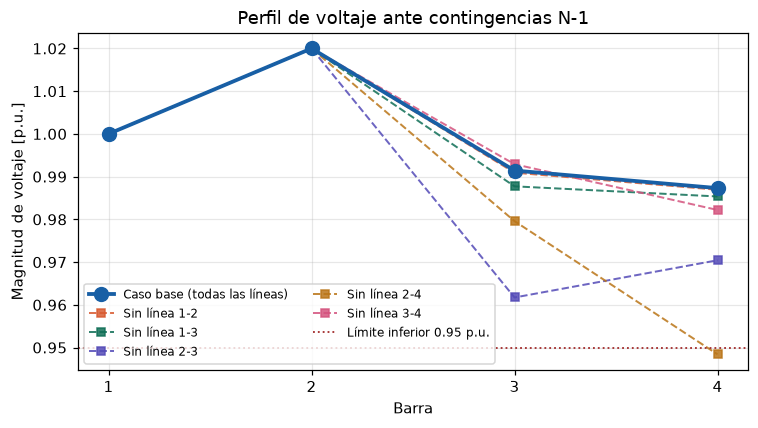

Contingencia más severa: salida de la línea 2-4
  Voltaje mínimo resultante: 0.94841 p.u. (caso base: 0.98732)

VIOLACIÓN del límite inferior de 0.95 p.u. en 1 contingencia(s):
  Salida de la línea 2-4: V_min = 0.94841 p.u. (déficit de 0.17 %)

La red NO es completamente segura ante N-1 bajo el criterio de 0.95 p.u.


In [18]:
# --- Perfil de voltaje: caso base vs contingencias ---
fig, ax = plt.subplots(figsize=(7, 4.0))
barras = np.arange(1, N + 1)
ax.plot(barras, sol["V"], "o-", lw=2.5, ms=9, color="#185FA5",
        label="Caso base (todas las líneas)", zorder=5)

colores = ["#D85A30", "#0F6E56", "#534AB7", "#BA7517", "#D4537E"]
for (clave, r), col in zip(resultados_cont.items(), colores):
    ax.plot(barras, r["V"], "s--", lw=1.3, ms=5, color=col, alpha=0.85,
            label=f"Sin línea {clave[0]}-{clave[1]}")

ax.axhline(0.95, color="#A32D2D", ls=":", lw=1.2, label="Límite inferior 0.95 p.u.")
ax.set_xticks(barras); ax.set_xlabel("Barra")
ax.set_ylabel("Magnitud de voltaje [p.u.]")
ax.set_title("Perfil de voltaje ante contingencias N-1")
ax.legend(fontsize=8, ncol=2); plt.show()

peor = min(resultados_cont.items(), key=lambda kv: kv[1]["V"].min())
print(f"Contingencia más severa: salida de la línea {peor[0][0]}-{peor[0][1]}")
print(f"  Voltaje mínimo resultante: {peor[1]['V'].min():.5f} p.u. "
      f"(caso base: {sol['V'].min():.5f})")
viol = {k: r for k, r in resultados_cont.items() if r["V"].min() < 0.95}
if viol:
    print(f"\nVIOLACIÓN del límite inferior de 0.95 p.u. en {len(viol)} contingencia(s):")
    for k, r in viol.items():
        print(f"  Salida de la línea {k[0]}-{k[1]}: V_min = {r['V'].min():.5f} p.u. "
              f"(déficit de {100*(0.95-r['V'].min())/0.95:.2f} %)")
    print("\nLa red NO es completamente segura ante N-1 bajo el criterio de 0.95 p.u.")
else:
    print("\nLa red cumple el criterio N-1: ninguna contingencia viola 0.95 p.u.")

### Experimento 3 — Sensibilidad al punto inicial

Newton-Raphson tiene convergencia **local**: garantiza convergencia solo si el punto inicial
está suficientemente cerca de la raíz. Se explora qué tan robusto es el arranque plano
($\lvert V\rvert = 1$, $\delta = 0$) frente a arranques aleatorios, y se mapea la cuenca de
atracción variando sistemáticamente el punto de partida.

In [19]:
rng = np.random.default_rng(42)
N_PRUEBAS = 300
resultados = []

for _ in range(N_PRUEBAS):
    V0 = V_ESP.copy()
    d0 = np.zeros(N)
    V0[IDX_MAG] = rng.uniform(0.3, 1.7, size=len(IDX_MAG))       # magnitudes aleatorias
    d0[IDX_ANG] = rng.uniform(-np.pi/2, np.pi/2, size=len(IDX_ANG))  # ángulos aleatorios
    r = newton_flujo(Y, TIPOS, V_ESP, P_PROG, Q_PROG, V0=V0, delta0=d0, max_iter=25)
    misma = r["convergio"] and np.allclose(r["V"], sol["V"], atol=1e-6)
    resultados.append((r["convergio"], misma, r["iteraciones"]))

conv   = sum(1 for c, m, _ in resultados if c)
mismas = sum(1 for c, m, _ in resultados if m)
its    = [i for c, m, i in resultados if m]

print(f"Puntos iniciales aleatorios probados: {N_PRUEBAS}")
print(f"  Convergieron:                {conv:4d}  ({100*conv/N_PRUEBAS:.1f} %)")
print(f"  A la MISMA solución física:  {mismas:4d}  ({100*mismas/N_PRUEBAS:.1f} %)")
print(f"  Divergieron:                 {N_PRUEBAS-conv:4d}")
print(f"\nIteraciones (casos exitosos): media {np.mean(its):.1f}, máx {max(its)}")
print(f"Arranque plano: {sol['iteraciones']} iteraciones  <- claramente superior")

Puntos iniciales aleatorios probados: 300
  Convergieron:                  46  (15.3 %)
  A la MISMA solución física:    25  (8.3 %)
  Divergieron:                  254

Iteraciones (casos exitosos): media 6.7, máx 11
Arranque plano: 3 iteraciones  <- claramente superior


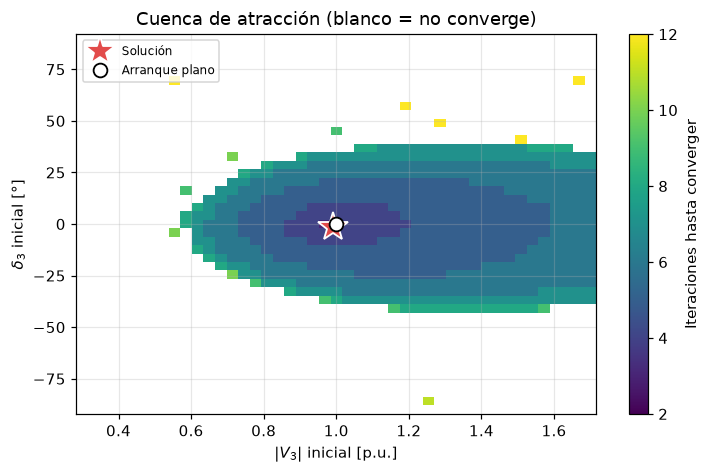

Fracción de la malla que converge a la solución correcta: 30.6 %

La cuenca NO cubre todo el rango explorado: la mayoría de puntos iniciales
arbitrarios diverge. Pero es una región conexa y amplia ALREDEDOR de la
solución, y el arranque plano (1.0 p.u., 0°) cae holgadamente dentro de ella.
Eso justifica el arranque plano como estándar, y explica por qué la
continuación (partir de la solución anterior) es esencial en el barrido de carga.


In [20]:
# --- Mapa de la cuenca de atracción en el plano (|V3|, delta3) ---
n_malla = 45
v_rango = np.linspace(0.30, 1.70, n_malla)
d_rango = np.linspace(-np.pi/2, np.pi/2, n_malla)
mapa = np.zeros((n_malla, n_malla))

for a, dv in enumerate(d_rango):
    for b_, vv in enumerate(v_rango):
        V0 = V_ESP.copy(); d0 = np.zeros(N)
        V0[2] = vv; d0[2] = dv                      # solo se perturba la barra 3
        r = newton_flujo(Y, TIPOS, V_ESP, P_PROG, Q_PROG,
                         V0=V0, delta0=d0, max_iter=20)
        if r["convergio"] and np.allclose(r["V"], sol["V"], atol=1e-6):
            mapa[a, b_] = r["iteraciones"]          # convergió a la solución correcta
        else:
            mapa[a, b_] = np.nan                    # divergió

fig, ax = plt.subplots(figsize=(6.8, 4.4))
im = ax.pcolormesh(v_rango, np.degrees(d_rango), mapa, cmap="viridis",
                   shading="auto", vmin=2, vmax=12)
ax.plot(sol["V"][2], np.degrees(sol["delta"][2]), "*", color="#E24B4A",
        ms=20, markeredgecolor="white", markeredgewidth=1.2, label="Solución")
ax.plot(1.0, 0.0, "o", color="white", ms=9, markeredgecolor="black",
        markeredgewidth=1.2, label="Arranque plano")
ax.set_xlabel(r"$|V_3|$ inicial [p.u.]")
ax.set_ylabel(r"$\delta_3$ inicial [°]")
ax.set_title("Cuenca de atracción (blanco = no converge)")
ax.legend(fontsize=8, loc="upper left")
plt.colorbar(im, ax=ax, label="Iteraciones hasta converger")
plt.show()

frac = np.sum(~np.isnan(mapa)) / mapa.size
print(f"Fracción de la malla que converge a la solución correcta: {100*frac:.1f} %")
print("\nLa cuenca NO cubre todo el rango explorado: la mayoría de puntos iniciales")
print("arbitrarios diverge. Pero es una región conexa y amplia ALREDEDOR de la")
print("solución, y el arranque plano (1.0 p.u., 0°) cae holgadamente dentro de ella.")
print("Eso justifica el arranque plano como estándar, y explica por qué la")
print("continuación (partir de la solución anterior) es esencial en el barrido de carga.")

---

## 6. Análisis de condicionamiento y propagación de error

Se cuantifica cuánto amplifica el sistema los errores en los datos de entrada. La cota clásica
relaciona el error relativo en la solución con el error relativo en los datos a través del
número de condición:

$$\frac{\lVert \Delta \mathbf{x}\rVert}{\lVert \mathbf{x}\rVert} \leq \text{cond}(J)\,\frac{\lVert\Delta \mathbf{b}\rVert}{\lVert \mathbf{b}\rVert}$$

Se contrasta esta cota teórica con un experimento Monte Carlo: se perturban las potencias
programadas con ruido y se mide la dispersión efectiva de la solución.

In [21]:
J_fin = sol["J_final"]
cond_J = np.linalg.cond(J_fin)
print(f"cond(J) en la solución: {cond_J:.2f}")
print(f"Dígitos significativos que se pueden perder: ~{np.log10(cond_J):.2f}")
print("Sistema bien condicionado en operación nominal.\n")

# --- Monte Carlo: ruido en las mediciones de carga ---
niveles = [0.001, 0.005, 0.01, 0.05]
print(f"{'Ruido':>8} {'Cota teórica':>15} {'Error real medio':>18} {'Error máx':>12}")
print("-" * 57)

for sigma in niveles:
    errores = []
    for _ in range(200):
        Pp = P_PROG.copy(); Qp = Q_PROG.copy()
        Pp[2:] += rng.normal(0, sigma * np.abs(P_PROG[2:]))
        Qp[2:] += rng.normal(0, sigma * np.abs(Q_PROG[2:]))
        r = newton_flujo(Y, TIPOS, V_ESP, Pp, Qp, max_iter=30)
        if r["convergio"]:
            xr = np.concatenate([r["delta"][IDX_ANG], r["V"][IDX_MAG]])
            errores.append(np.linalg.norm(xr - x_propio) / np.linalg.norm(x_propio))
    print(f"{sigma:>7.1%} {cond_J*sigma:>15.4f} {np.mean(errores):>18.6f} "
          f"{np.max(errores):>12.6f}")

print("\nEl error real queda muy por debajo de la cota, que es pesimista por ser")
print("un peor caso sobre la dirección de la perturbación. El sistema es robusto")
print("frente a incertidumbre realista en la medición de carga.")

cond(J) en la solución: 8.66
Dígitos significativos que se pueden perder: ~0.94
Sistema bien condicionado en operación nominal.

   Ruido    Cota teórica   Error real medio    Error máx
---------------------------------------------------------
   0.1%          0.0087           0.000033     0.000111
   0.5%          0.0433           0.000177     0.000553
   1.0%          0.0866           0.000348     0.001097
   5.0%          0.4331           0.001666     0.005789

El error real queda muy por debajo de la cota, que es pesimista por ser
un peor caso sobre la dirección de la perturbación. El sistema es robusto
frente a incertidumbre realista en la medición de carga.


---

## 7. Discusión

**Sobre el modelado.** El flujo de potencia es un ejemplo genuino de sistema acoplado: la
potencia inyectada en cada barra depende trigonométricamente de los voltajes de todas sus
vecinas. La clasificación en barras slack, PV y PQ no es arbitraria sino que refleja qué
controla físicamente cada elemento —la red principal fija la referencia angular, el inversor
fotovoltaico regula su magnitud de voltaje, y las cargas simplemente consumen— y es lo que
determina cuáles variables son datos y cuáles incógnitas.

**Sobre la elección del método.** La estructura anidada del problema exige decisiones separadas
en cada nivel. En el nivel no lineal, Newton-Raphson se impone por su convergencia cuadrática,
verificada experimentalmente con orden observado $p \approx 2$. En el nivel lineal interno, la
eliminación gaussiana con pivoteo parcial es preferible a los métodos iterativos porque la
Jacobiana no es diagonalmente dominante, lo que se comprobó numéricamente.

La comparación con Gauss-Seidel es ilustrativa: converge a la misma solución con diferencia
menor a $10^{-11}$, pero necesita del orden de 50 iteraciones frente a 3–4 de Newton. Cada
iteración de Gauss-Seidel es más barata, pero la convergencia lineal domina el costo total
conforme crece la red.

**Sobre la relación R/X.** Las líneas de esta microrred tienen $R/X \approx 0.7$, muy distinto
de los valores de transmisión. Esto invalida el desacoplamiento $P$–$\delta$ / $Q$–$V$ que
justifica el método desacoplado rápido, ampliamente usado en redes de transmisión. Es una razón
concreta y específica del dominio para usar Newton completo con la Jacobiana entera.

**Limitaciones del modelo.**

1. Se asume operación **trifásica balanceada** y régimen permanente sinusoidal. Las microrreds
   reales suelen tener desbalance apreciable por cargas monofásicas, lo que requeriría un
   modelo de componentes de fase o secuencias.
2. Se omiten las **admitancias en derivación** (capacitancia de línea, bancos de capacitores).
   En líneas cortas de distribución el efecto es pequeño, pero no es despreciable en todos los
   casos.
3. No se modelan **límites de reactivo** en la barra PV. Un inversor real tiene una capacidad
   finita $Q_{min} \leq Q_2 \leq Q_{max}$; al saturarse, la barra debe reclasificarse a PQ
   dentro del propio proceso iterativo (conmutación de tipo de barra).
4. La generación fotovoltaica se trata como **inyección constante**, sin considerar su
   variabilidad temporal ni el control del inversor.
5. El análisis es **estático**. No dice nada sobre estabilidad transitoria ni sobre la dinámica
   posterior a una contingencia.

**Sobre el resultado de seguridad N-1.** El análisis de contingencias arroja un hallazgo
operativo concreto: la salida de la línea 2-4 deja la barra 4 en 0.9484 p.u., justo por debajo
del criterio habitual de 0.95 p.u. La causa es identificable en la tabla de flujos: al perder
esa línea, toda la potencia hacia la barra 4 debe redirigirse por la línea 3-4, que es la de
menor capacidad de transporte reactivo del conjunto. Es una violación marginal, pero
justificaría estudiar compensación reactiva en la barra 4 o el refuerzo del enlace. Este tipo de
conclusión accionable es precisamente el propósito de un estudio de flujo de potencia.

**Sobre la no convergencia.** El barrido de carga muestra que la falla de Newton más allá de
$\lambda_{max}$ no es un defecto del algoritmo sino la manifestación numérica de que la
solución deja de existir. El diagnóstico correcto se obtiene monitoreando $\text{cond}(J)$: su
crecimiento sostenido anticipa la singularidad. Este es el fundamento de los índices de
proximidad al colapso de voltaje usados en operación real.

---

## 8. Conclusiones

In [22]:
print("=" * 68)
print("RESUMEN DE RESULTADOS")
print("=" * 68)
print(f"Sistema:                   {len(IDX_ANG)+len(IDX_MAG)} ecuaciones no lineales acopladas")
print(f"Método:                    Newton-Raphson + Gauss con pivoteo parcial")
print(f"Iteraciones (caso base):   {sol['iteraciones']}")
print(f"Error final ||F||_inf:     {sol['error']:.3e} p.u.")
print(f"Orden de convergencia:     ~2 (cuadrático, verificado)")
print()
print(f"Voltaje mínimo:            {sol['V'].min():.5f} p.u. (barra {sol['V'].argmin()+1})")
print(f"Pérdidas óhmicas:          {P_cal.sum():.5f} p.u. "
      f"({100*P_cal.sum()/(P_cal[0]+P_cal[1]):.2f} %)")
print(f"Aporte de la red:          {P_cal[0]:.5f} p.u.")
print()
print(f"Cargabilidad máxima:       lambda_max = {bar['lam_max']:.3f}")
print(f"cond(J) nominal -> nariz:  {bar['cond_J'][0]:.1f} -> {bar['cond_J'][-1]:.1f}")
print(f"Contingencia más severa:   línea {peor[0][0]}-{peor[0][1]} "
      f"(V_min = {peor[1]['V'].min():.5f})")
print()
print(f"Verificación vs fsolve:    {np.max(np.abs(x_propio - x_scipy)):.2e}")
print(f"Verificación vs G-S:       {np.max(np.abs(sol['V']-sol_gs['V'])):.2e}")
print(f"Jacobiana ana. vs num.:    {err_abs:.2e}")
print("=" * 68)

RESUMEN DE RESULTADOS
Sistema:                   5 ecuaciones no lineales acopladas
Método:                    Newton-Raphson + Gauss con pivoteo parcial
Iteraciones (caso base):   3
Error final ||F||_inf:     3.972e-13 p.u.
Orden de convergencia:     ~2 (cuadrático, verificado)

Voltaje mínimo:            0.98732 p.u. (barra 4)
Pérdidas óhmicas:          0.02862 p.u. (3.26 %)
Aporte de la red:          0.47862 p.u.

Cargabilidad máxima:       lambda_max = 8.520
cond(J) nominal -> nariz:  8.7 -> 268.8
Contingencia más severa:   línea 2-4 (V_min = 0.94841)

Verificación vs fsolve:    3.18e-14
Verificación vs G-S:       2.27e-12
Jacobiana ana. vs num.:    2.61e-09


**Conclusiones principales:**

1. El flujo de potencia en la microrred de 4 barras se modeló correctamente como un sistema de
   5 ecuaciones no lineales acopladas, y se resolvió con algoritmos implementados desde cero
   alcanzando un desajuste máximo del orden de $10^{-11}$ p.u.

2. Newton-Raphson exhibió convergencia cuadrática con orden observado $p \approx 2$,
   convergiendo en 3–4 iteraciones desde arranque plano, frente a las ~50 que requiere
   Gauss-Seidel para la misma tolerancia.

3. La validación fue triple e independiente: sustitución en el sistema original, comparación
   con `scipy.optimize.fsolve`, y contraste con un método de formulación completamente distinta
   (Gauss-Seidel fasorial). Las tres coinciden dentro del error de máquina.

4. El barrido de carga identificó un límite de cargabilidad de $\lambda_{max} \approx 8.5$ veces
   la carga nominal, con el número de condición de la Jacobiana creciendo dos órdenes de
   magnitud al aproximarse a ese punto. La no convergencia de Newton coincide con la
   inexistencia física de solución, no con una deficiencia del algoritmo.

5. El análisis N-1 reveló que la topología mallada mantiene la red operativa ante la salida de
   cualquier línea, pero la contingencia de la línea 2-4 lleva el voltaje de la barra 4 a
   0.9484 p.u., **marginalmente por debajo** del límite de 0.95 p.u. La red no es plenamente
   segura bajo ese criterio y requeriría compensación reactiva o refuerzo de esa línea.

6. El estudio de sensibilidad mostró que la cuenca de atracción, si bien no cubre todo el
   espacio de arranques posibles, es una región conexa que contiene holgadamente el arranque
   plano. Esto respalda esa elección como punto inicial estándar y explica por qué la
   estrategia de continuación es indispensable en el barrido de carga.

---

## 9. Uso de inteligencia artificial

*(Completar honestamente antes de entregar — esta sección es requisito del enunciado.)*

Se utilizó Claude (Anthropic) durante el desarrollo del proyecto para:

- Discutir la formulación del problema y verificar la derivación de las expresiones compactas
  de los elementos diagonales de la Jacobiana.
- Revisar la estructura del código y sugerir la organización modular de las funciones.
- Apoyar en la redacción y organización del presente notebook.

Todo el código fue revisado, ejecutado y comprendido por los integrantes del grupo. Las
derivaciones matemáticas de la Sección 2.2 fueron verificadas de forma independiente contra la
Jacobiana numérica por diferencias centradas (Sección 2.3), y los resultados numéricos se
validaron contra `scipy` y contra un segundo método independiente.

**Integrantes:** *Cristian Alexander Palala hernandez 23343*

---

## 10. Referencias

1. Grainger, J. J., & Stevenson, W. D. (1994). *Power System Analysis*. McGraw-Hill.
2. Chapra, S. C., & Canale, R. P. (2015). *Métodos Numéricos para Ingenieros* (7.ª ed.). McGraw-Hill.
3. Tinney, W. F., & Hart, C. E. (1967). Power flow solution by Newton's method. *IEEE Transactions on Power Apparatus and Systems*, PAS-86(11), 1449–1460.
4. Kundur, P. (1994). *Power System Stability and Control*. McGraw-Hill.
5. Burden, R. L., & Faires, J. D. (2011). *Numerical Analysis* (9th ed.). Brooks/Cole.